# **Redes Neuronales Convolucionales (CNN): Clasificación de imagenes**

# **Configuracion inicial**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sns.set_style("white")
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 125s 1us/step
X_train: (50000, 32, 32, 3)  X_test: (10000, 32, 32, 3)
X_train(perros): (5000, 32, 32, 3)


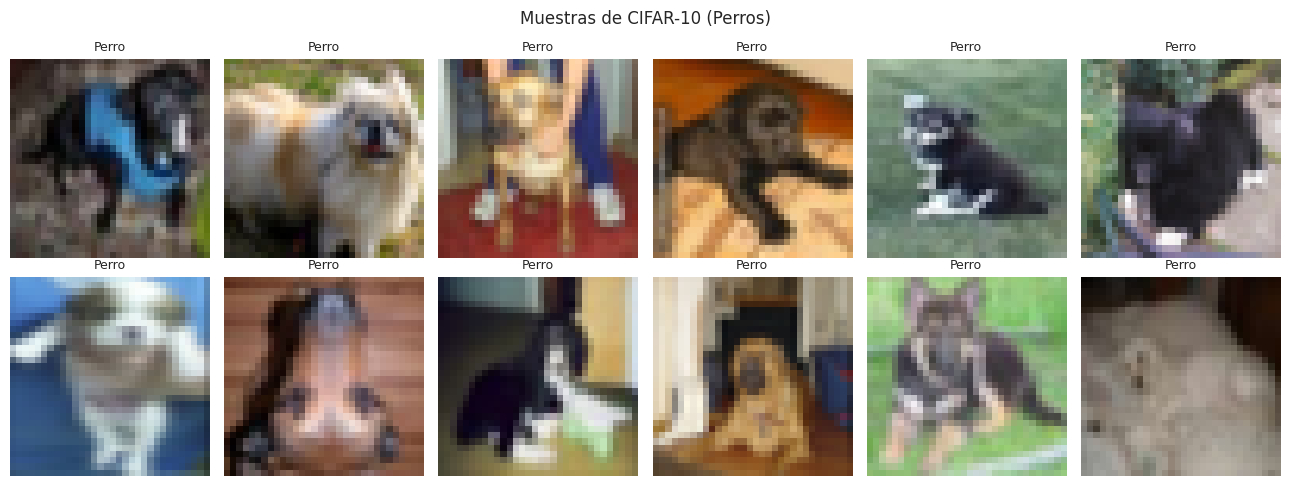

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)
CLASE_PERRO = 5

print("X_train:", X_train.shape, " X_test:", X_test.shape)

indices_train_perros = np.where(y_train == CLASE_PERRO)[0]
indices_test_perros = np.where(y_test == CLASE_PERRO)[0]

X_train = X_train[indices_train_perros]
y_train = y_train[indices_train_perros]

X_test = X_test[indices_test_perros]
y_test = y_test[indices_test_perros]
Nombres_clases = ["Perro"]
print("X_train(perros):", X_train.shape)
fig, ejes = plt.subplots(2, 6, figsize=(13, 5))
for i, ax in enumerate(ejes.flat):
    ax.imshow(X_train[i]) # Sin cmap="gray" porque es a color
    ax.set_title(Nombres_clases[0], fontsize=9)
    ax.axis("off")

plt.suptitle("Muestras de CIFAR-10 (Perros)")
plt.tight_layout()
plt.show()


# **¿Por qué una CNN y no un MLP simple?**

In [ ]:
parametros_mlp_capa1 = (32 * 28 * 3) * 128 + 128
parametros_conv_capa1 = (3 * 3 * 3) * 32 + 32  # 32 filtros de 3x3 sobre 1 canal

print(f"Parámetros de una capa Dense(128) sobre la imagen aplanada: {parametros_mlp_capa1:,}")
print(f"Parámetros de una capa Conv2D(32, kernel 3x3):              {parametros_conv_capa1:,}")
print(f"\n-> La capa convolucional usa {parametros_mlp_capa1 / parametros_conv_capa1:.0f}x menos parámetros "
      f"en esta primera capa, y aun así puede cubrir toda la imagen a color.")

Parámetros de una capa Dense(128) sobre la imagen aplanada: 344,192
Parámetros de una capa Conv2D(32, kernel 3x3):              896

-> La capa convolucional usa 384x menos parámetros en esta primera capa, y aun así puede cubrir toda la imagen a color.


# **Preparar los datos**

In [ ]:
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

X_train_norm = X_train_norm.reshape(-1, 32, 32, 3)
X_test_norm = X_test_norm.reshape(-1, 32, 32, 3)

print("Forma final:", X_train_norm.shape, " Rango de valores:", X_train_norm.min(), "a", X_train_norm.max())

Forma final: (5000, 32, 32, 3)  Rango de valores: 0.0 a 1.0


# **Construir la arquitectura**

In [ ]:
modelo_cnn = keras.Sequential([
    layers.Input(shape=(32, 32, 3)), # <--- Entrada 32x32x3
    layers.Conv2D(32, kernel_size=3, activation="relu", name="conv_1"),
    layers.MaxPooling2D(pool_size=2, name="pool_1"),
    layers.Conv2D(64, kernel_size=3, activation="relu", name="conv_2"),
    layers.MaxPooling2D(pool_size=2, name="pool_2"),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid"), # <--- CAMBIO 2: 1 neurona para detección binaria
])

modelo_cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy", # <--- CAMBIO 3: Pérdida binaria
    metrics=["accuracy"]
)
modelo_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,977 (652.25 KB)

 Trainable params: 166,977 (652.25 KB)

 Non-trainable params: 0 (0.00 B)

# **Entrenar y evaluar**

In [ ]:
historial = modelo_cnn.fit(
    X_train_norm, y_train, epochs=6, batch_size=128,
    validation_split=0.2, verbose=1,
)

Epoch 1/6
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.0000e+00 - loss: -1325.9703 - val_accuracy: 0.0000e+00 - val_loss: -7566.9365
Epoch 2/6
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.0000e+00 - loss: -52103.0039 - val_accuracy: 0.0000e+00 - val_loss: -166281.4375
Epoch 3/6
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.0000e+00 - loss: -505979.1250 - val_accuracy: 0.0000e+00 - val_loss: -1163540.0000
Epoch 4/6
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.0000e+00 - loss: -2462486.5000 - val_accuracy: 0.0000e+00 - val_loss: -4656874.0000
Epoch 5/6
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.0000e+00 - loss: -8106716.0000 - val_accuracy: 0.0000e+00 - val_loss: -13520680.0000
Epoch 6/6
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - accuracy: 0.0000e+00 - loss: -20872834.0000 - val_accuracy: 0.0000e+00 - val_loss: -31933376.0000


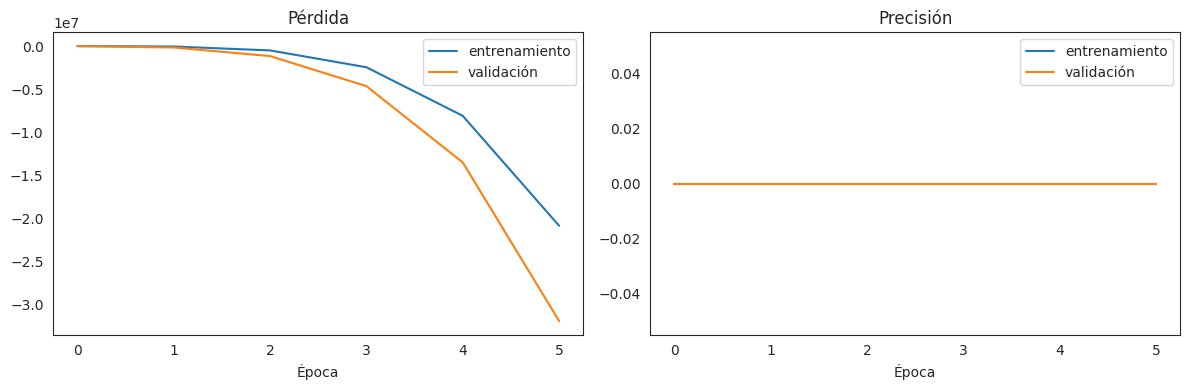

Precisión en test: 0.0000


In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
ejes[0].plot(historial.history["loss"], label="entrenamiento")
ejes[0].plot(historial.history["val_loss"], label="validación")
ejes[0].set_title("Pérdida"); ejes[0].set_xlabel("Época"); ejes[0].legend()

ejes[1].plot(historial.history["accuracy"], label="entrenamiento")
ejes[1].plot(historial.history["val_accuracy"], label="validación")
ejes[1].set_title("Precisión"); ejes[1].set_xlabel("Época"); ejes[1].legend()

plt.tight_layout()
plt.show()

perdida_test, precision_test = modelo_cnn.evaluate(X_test_norm, y_test, verbose=0)
print(f"Precisión en test: {precision_test:.4f}")

# **Ve "por dentro" dela red: filtros aprendidos**

Forma de los filtros: (3, 3, 3, 32)


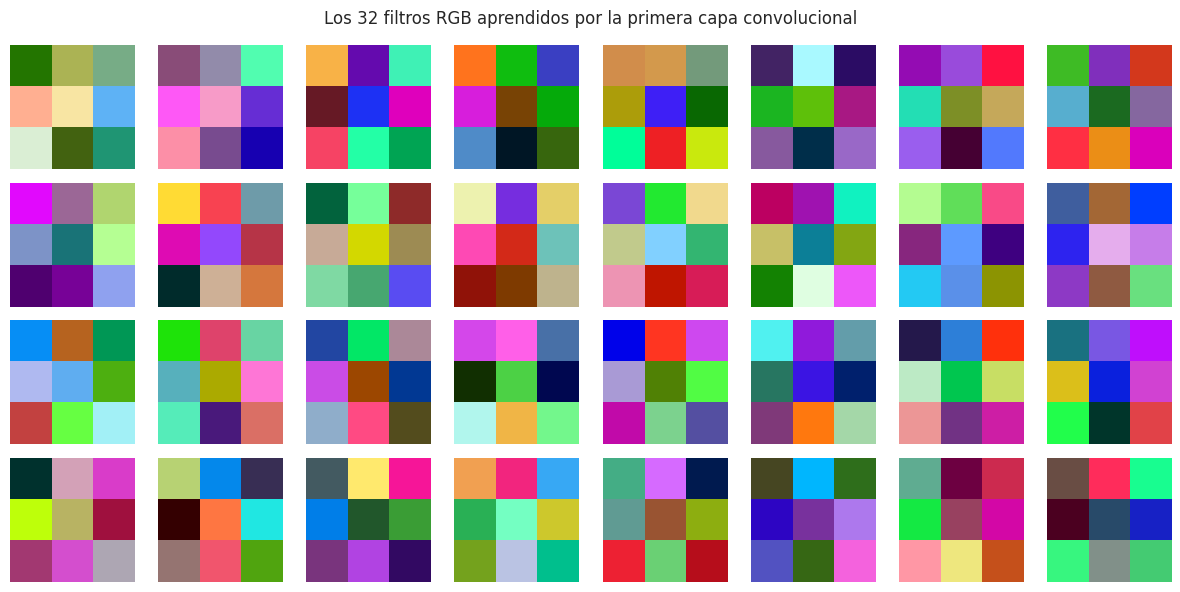

In [ ]:
pesos_conv1, sesgos_conv1 = modelo_cnn.get_layer("conv_1").get_weights()
print("Forma de los filtros:", pesos_conv1.shape)  # Salida: (3, 3, 3, 32)

fig, ejes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(ejes.flat):
    # Extraer el filtro RGB i
    filtro = pesos_conv1[:, :, :, i]
    # Normalizar valores a [0, 1] para poder mostrar la imagen a color
    filtro_norm = (filtro - filtro.min()) / (filtro.max() - filtro.min() + 1e-8)

    ax.imshow(filtro_norm) # Se remueve cmap="gray" porque el filtro es RGB
    ax.axis("off")

plt.suptitle("Los 32 filtros RGB aprendidos por la primera capa convolucional")
plt.tight_layout()
plt.show()

# **Mapas de características**

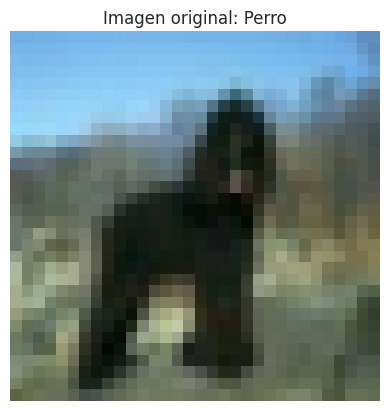

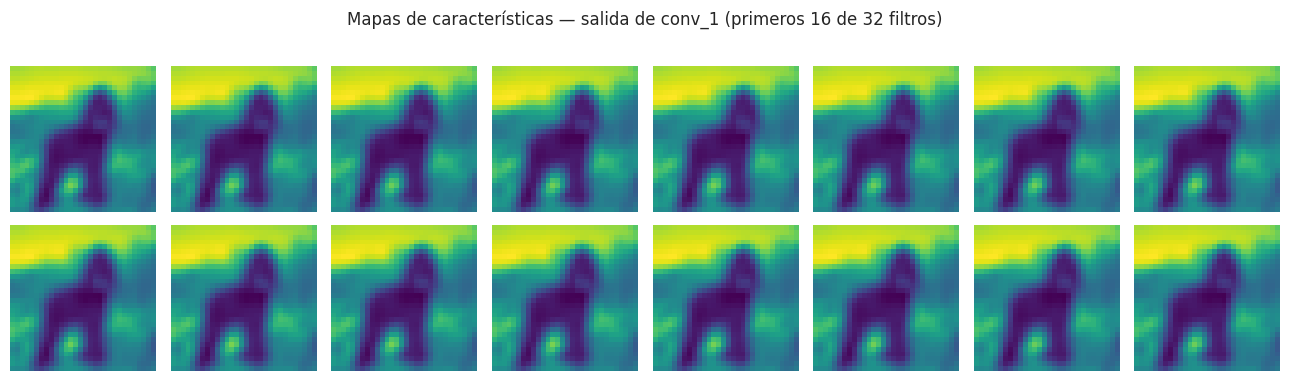

In [ ]:
modelo_extractor = keras.Model(
    inputs=modelo_cnn.inputs,
    outputs=[
        modelo_cnn.get_layer("conv_1").output,
        modelo_cnn.get_layer("conv_2").output
    ]
)

indice_muestra = 7
imagen_muestra = X_test_norm[indice_muestra:indice_muestra + 1]
mapas_conv1, mapas_conv2 = modelo_extractor.predict(imagen_muestra, verbose=0)

# Visualizar la imagen original a color
plt.imshow(X_test[indice_muestra]) # Se quitó cmap="gray"
plt.title(f"Imagen original: {Nombres_clases[0]}")
plt.axis("off")
plt.show()

# Visualizar los mapas de características
fig, ejes = plt.subplots(2, 8, figsize=(13, 4))
for i, ax in enumerate(ejes.flat):
    ax.imshow(mapas_conv1[0, :, :, i], cmap="viridis")
    ax.axis("off")

plt.suptitle("Mapas de características — salida de conv_1 (primeros 16 de 32 filtros)")
plt.tight_layout()
plt.show()

# **Evaluación: matriz de confusión y errores**

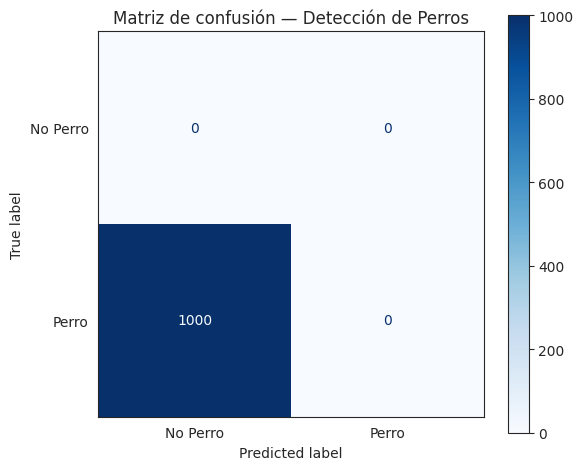

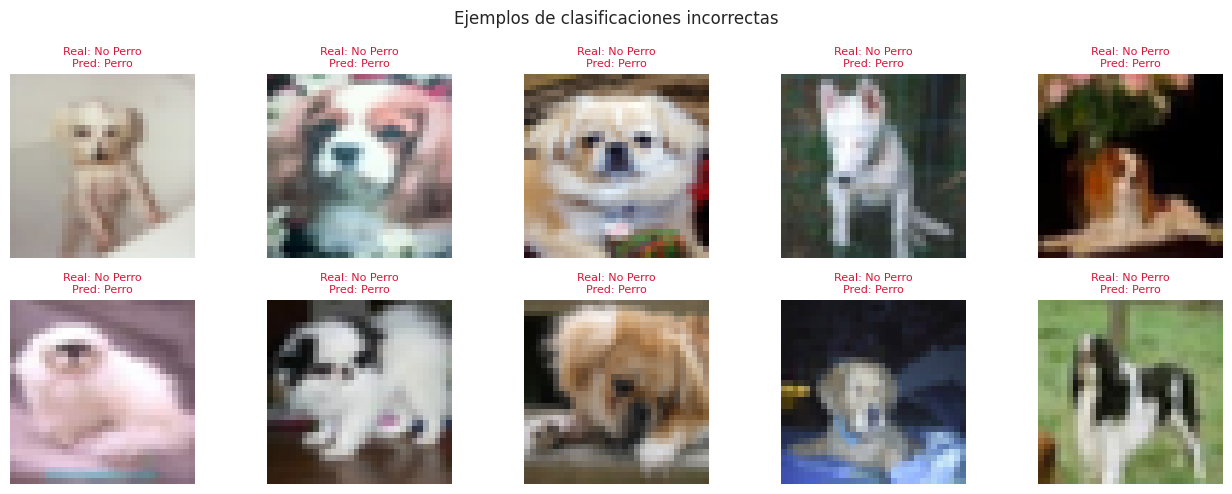

In [ ]:
y_pred_probs = modelo_cnn.predict(X_test_norm, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)

# Matriz de confusión 2x2
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Perro", "Perro"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues")
plt.title("Matriz de confusión — Detección de Perros")
plt.tight_layout()
plt.show()

# Visualizar algunos errores
indices_error = np.where(y_pred != y_test)[0]
if len(indices_error) > 0:
    muestra_errores = np.random.choice(indices_error, size=min(10, len(indices_error)), replace=False)

    fig, ejes = plt.subplots(2, 5, figsize=(13, 5))
    for idx, ax in zip(muestra_errores, ejes.flat):
        ax.imshow(X_test[idx])
        etiqueta_real = "Perro" if y_test[idx] == 1 else "No Perro"
        etiqueta_pred = "Perro" if y_pred[idx] == 1 else "No Perro"
        ax.set_title(f"Real: {etiqueta_real}\nPred: {etiqueta_pred}", fontsize=8, color="crimson")
        ax.axis("off")

    plt.suptitle("Ejemplos de clasificaciones incorrectas")
    plt.tight_layout()
    plt.show()